# Survey Data with Pandas and StatsModels

Tutorial for PyCon 2025

Allen B. Downey

[Click here to run this notebook on Colab](https://colab.research.google.com/github/AllenDowney/SurveyDataPandas/blob/main/notebooks/01_simpson.ipynb).

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
# Configure Matplotlib

plt.rcParams["figure.figsize"] = 7, 3.5
plt.rcParams["figure.dpi"] = 75
plt.rcParams["axes.titlelocation"] = "left"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.bottom"] = False
plt.rcParams["axes.spines.left"] = False
plt.rcParams["axes.spines.right"] = False

In [38]:
from os.path import basename, exists

def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve
        local, _ = urlretrieve(url, filename)
        print('Downloaded ' + local)

In [39]:
def decorate(**options):
    """Decorate the current axes.

    Call decorate with keyword arguments like
    decorate(title='Title',
             xlabel='x',
             ylabel='y')

    The keyword arguments can be any of the axis properties
    https://matplotlib.org/api/axes_api.html
    """
    legend = options.pop("legend", True)
    loc = options.pop("loc", "best")

    # Pass options to Axis.set
    ax = plt.gca()
    ax.set(**options)

    # Add a legend if there are any labeled elements
    handles, labels = ax.get_legend_handles_labels()
    if handles and legend:
        ax.legend(handles, labels, loc=loc)

    # Tight layout is generally a good idea
    plt.tight_layout()

## Data

We will use data from the [General Social Survey](https://gss.norc.org/) (GSS).
The raw dataset is big, so I've prepared an extract, which the following cell downloads.
The code to generate the extract is [in this notebook](https://github.com/AllenDowney/GssExtract/blob/main/notebooks/02_make_extract-2022_4.ipynb).

In [40]:
# This dataset is prepared in the GssExtract repository

DATA_PATH = "https://github.com/AllenDowney/GssExtract/raw/main/data/interim/"

filename = "gss_extract_pacs_workshop.hdf"
download(DATA_PATH + filename)

In [41]:
gss = pd.read_hdf(filename)
type(gss)
gss.head()

,age,attend,ballot,class,cohort,degree,educ,fair,fear,goodlife,...,region,relig,rincome,satfin,satjob,sex,srcbelt,trust,wtssall,year
0,24.0,1.0,NaN,3.0,1948.0,3.0,16.0,2.0,NaN,NaN,...,1,1.0,NaN,1.0,NaN,1.0,5.0,1.0,1.3339,1972
1,33.0,2.0,NaN,2.0,1939.0,0.0,10.0,2.0,NaN,NaN,...,1,2.0,NaN,3.0,2.0,1.0,1.0,1.0,0.8893,1972
2,40.0,8.0,NaN,2.0,1932.0,1.0,12.0,2.0,NaN,NaN,...,1,5.0,NaN,1.0,NaN,2.0,3.0,2.0,1.3339,1972
3,24.0,2.0,NaN,2.0,1948.0,1.0,12.0,1.0,NaN,NaN,...,9,2.0,NaN,2.0,NaN,1.0,3.0,2.0,1.7786,1972
4,21.0,7.0,NaN,3.0,1951.0,1.0,12.0,1.0,NaN,NaN,...,9,1.0,NaN,1.0,NaN,2.0,2.0,NaN,1.7786,1972


In [42]:
gss.shape

(72390, 29)

In [43]:
gss.columns

Index(['age', 'attend', 'ballot', 'class', 'cohort', 'degree', 'educ', 'fair',
       'fear', 'goodlife', 'hapmar', 'happy', 'health', 'helpful', 'id',
       'life', 'partyid', 'polviews', 'race', 'region', 'relig', 'rincome',
       'satfin', 'satjob', 'sex', 'srcbelt', 'trust', 'wtssall', 'year'],
      dtype='object')

In [44]:
gss.isna().mean().sort_values() * 100
# provides percentage in each column that is missing

,0
id,0.000000
year,0.000000
wtssall,0.000000
region,0.000000
srcbelt,0.071833
race,0.179583
sex,0.208592
degree,0.294240
educ,0.433762
cohort,0.556707


## Distributions

We'll see two ways to describe distributions: value counts and KDE.

And for joint distributions, we'll use a cross tabulation.

In [45]:
def value_counts(seq, **options):
    """Make a series of values and the number of times they appear.

    Args:
        seq: sequence

    returns: Pandas Series
    """
    return pd.Series(seq).value_counts(**options).sort_index()

In [46]:
type(gss['year']) # this is a series

pandas.core.series.Series

In [47]:
gss['year'].value_counts().sort_index() # pandas built-in value_counts

,count
year,
1972,1613
1973,1504
1974,1484
1975,1490
1976,1499
1977,1530
1978,1532
1980,1468
1982,1860


<Axes: xlabel='year'>

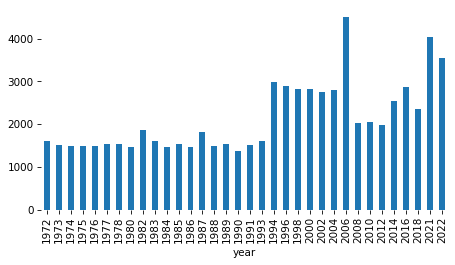

In [48]:
pmf = value_counts(gss['year'], dropna=False) # custom wrapper function
pmf.plot(kind='bar')

In [49]:
gss['age'].describe()

,age
count,71636.000000
mean,44.985943
std,17.201666
min,18.000000
25%,30.000000
50%,43.000000
75%,58.000000
max,89.000000


<Axes: xlabel='age', ylabel='Density'>

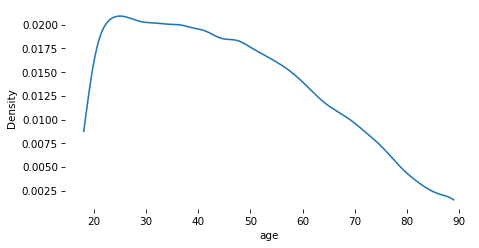

In [50]:
sns.kdeplot(gss['age'], cut=0)

In [51]:
gss['cohort'].describe() # year of birth

,cohort
count,71987.000000
mean,1991.908095
std,561.717010
min,1883.000000
25%,1938.000000
50%,1954.000000
75%,1968.000000
max,9999.000000


In [52]:
gss['cohort'] = gss['cohort'].replace(9999, np.nan)
gss['cohort'].describe() # year of birth

,cohort
count,71635.000000
mean,1952.562853
std,21.977789
min,1883.000000
25%,1938.000000
50%,1954.000000
75%,1967.000000
max,2004.000000


### Exercise

Use `value_counts` to plot the distribution of `cohort` as a bar plot.
Then use `sns.kdeplot` to show the same distribution as a continuous quantity.

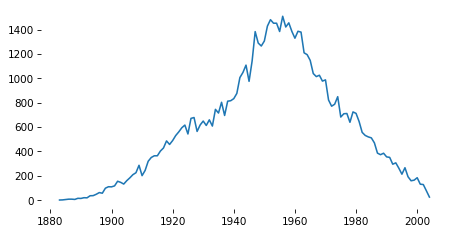

In [72]:
pmf_age = value_counts(gss['cohort'], dropna=False) # custom wrapper function
x = pmf_age.index
y = pmf_age.values
plt.plot(x, y) # matplotlib

<Axes: xlabel='cohort', ylabel='Density'>

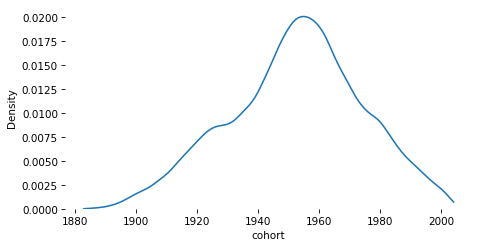

In [69]:
sns.kdeplot(gss['cohort'], cut=0)

## Cross tabulation

Cross tabulation is a way to represent the joint distribution of two variables.

## Target variable

I've selected four variables you might want to work with.
Whichever one you choose, put its cell last.

In [63]:
# https://gssdataexplorer.norc.org/variables/439/vshow

varname = 'helpful'

question = """Would you say that most of the time people try to be helpful,
or that they are mostly just looking out for themselves?
"""

responses = ['Helpful', 'Look out\nfor themselves', 'Depends']

ylabel = "Percent saying 'helpful'"

In [64]:
# https://gssdataexplorer.norc.org/variables/440/vshow

varname = 'fair'

question = """Do you think most people would try to take advantage of you
if they got a chance, or would they try to be fair?
"""

# notice that the negative response is first here!
responses = ['Take advantage', 'Fair', 'Depends']

ylabel = "Percent saying 'fair'"

In [65]:
# https://gssdataexplorer.norc.org/variables/441/vshow

varname = 'trust'

question = """Generally speaking, would you say that most people can be trusted
or that you can't be too careful in dealing with people?
"""

responses = ['Trusted', "Can't be\ntoo careful", 'Depends']

ylabel = "Percent saying 'trusted'"

In [66]:
# https://gssdataexplorer.norc.org/variables/434/vshow

varname = 'happy'

question = """Taken all together, how would you say things are these days--
would you say that you are very happy, pretty happy, or not too happy?
"""

responses = ['Very happy', "Happy", 'Not too happy']

ylabel = "Percent saying 'very happy'"

### Exercise

Do you think people who say "trust" are also more likely to say "helpful"?
To find out, make a cross tabulation of `trust` and `helpful`.
Consider using `normalize='index'`.
Make a heatmap that shows this joint distribution.
What relationships can you see in the responses?

In [67]:
gss['happy'].describe()

,happy
count,67677.000000
mean,1.809847
std,0.640736
min,1.000000
25%,1.000000
50%,2.000000
75%,2.000000
max,3.000000


## Time Series

To see how responses have changed over time, we'll use cross tabulation again.

## Smoothing

To smooth the time series, we'll use LOWESS (locally weighted scatterplot smoothing).

In [57]:
def make_lowess(series, frac=0.5):
    """Use LOWESS to compute a smooth line.

    series: pd.Series

    returns: pd.Series
    """
    y = series.to_numpy()
    x = series.index.to_numpy()

    smooth_array = lowess(y, x, frac)
    index, data = np.transpose(smooth_array)

    return pd.Series(data, index=index)

### Exercise

Use this function to make `smooth_series`.
Plot the result along with `time_series`.

## Binary series

It will be useful to convert the responses to a binary variable represented with 0s and 1s.

## Pivot tables

Now we'll use a pivot table to put respondents in groups and see how the responses have changed over time.

In [58]:
polviews_map = {
    1: 'Liberal',
    2: 'Liberal',
    3: 'Liberal',
    4: 'Moderate',
    5: 'Conservative',
    6: 'Conservative',
    7: 'Conservative',
}

## Better colors

We'll select colors from a Seaborn color palette.

### Exercise

Loop through the groups in `color_map`.
For each one, extract a column from `table` and plot the data points; then plot a smooth line.

## Groupby

Now that we have `y` as a binary variable, we have another way to compute the time series and the pivot table.
There are pros and cons of each method.

## Logistic regression

We'll use logistic regression to model changes over time.

In [59]:
def fit_model(data, x_range, x_shift):
    formula = 'y ~ x + I(x**2)'
    model = smf.logit(formula, data=data).fit(disp=False)

    pred_df = pd.DataFrame(dict(x=x_range - x_shift))
    pred = model.predict(pred_df) * 100
    pred.index = x_range
    pred.name = 'model'

    return pred

### Exercise

Use `subset.groupby('polviews3')` to loop through the groups.
For each one, use `fit_model` to generate and plot a "prediction" for the group.

## Group by cohort

Now let's group respondents by decade of birth and see how each cohort changes over time.


In [60]:
def round_into_bins(series, bin_width, low=0, high=None):
    """Rounds values down to the bin they belong in.

    series: pd.Series
    bin_width: number, width of the bins

    returns: Series of bin values (with NaN preserved)
    """
    if high is None:
        high = series.max()

    bins = np.arange(low, high + bin_width, bin_width)
    indices = np.digitize(series, bins)
    result = pd.Series(bins[indices - 1], index=series.index, dtype='float')

    result[series.isna()] = np.nan
    return result

## All the Cohorts

Now let's compare cohorts. The following function encapsulates the steps from the previous section.

In [61]:
def plot_cohort(df, cohort, color='C0'):
    cohort_df = df.query("cohort10 == @cohort").dropna(subset=['y', 'x'])

    cohort_series = cohort_df.groupby('year')['y'].mean() * 100

    year_range = cohort_series.index

    pred_series = fit_model(cohort_df, year_range, year_shift)
    x, y = pred_series.index[-1], pred_series.values[-1]
    plt.text(x, y, cohort, ha='left', va='center')

    pred_series.plot(label=cohort, color=color)

### Exercise

Plot `pred_all`.
Then loop through `cohorts` and `colors`, and call `plot_cohort` for each group.

Depending on which target variable you chose, you might get a warning from StatsModels.

## Simpson's Paradox

The composition of the population changes over time.


## Sampling weights

The GSS uses stratified sampling, so some respondents represent more people in the population than others.
We can use resampling to correct for stratified sampling.

In [62]:
def resample_by_year(df, column='wtssall'):
    """Resample rows within each year using weighted sampling.

    df: DataFrame
    column: string name of weight variable

    returns: DataFrame
    """
    grouped = df.groupby('year')
    samples = [group.sample(n=len(group), replace=True, weights=group[column])
               for _, group in grouped]
    sample = pd.concat(samples, ignore_index=True)
    return sample


Copyright 2025 Allen Downey

The code in this notebook is under the [MIT license](https://mit-license.org/).